In [2]:
# %BANNER_BEGIN%
# ---------------------------------------------------------------------
# %COPYRIGHT_BEGIN%
#
#  Magic Leap, Inc. ("COMPANY") CONFIDENTIAL
#
#  Unpublished Copyright (c) 2020
#  Magic Leap, Inc., All Rights Reserved.
#
# NOTICE:  All information contained herein is, and remains the property
# of COMPANY. The intellectual and technical concepts contained herein
# are proprietary to COMPANY and may be covered by U.S. and Foreign
# Patents, patents in process, and are protected by trade secret or
# copyright law.  Dissemination of this information or reproduction of
# this material is strictly forbidden unless prior written permission is
# obtained from COMPANY.  Access to the source code contained herein is
# hereby forbidden to anyone except current COMPANY employees, managers
# or contractors who have executed Confidentiality and Non-disclosure
# agreements explicitly covering such access.
#
# The copyright notice above does not evidence any actual or intended
# publication or disclosure  of  this source code, which includes
# information that is confidential and/or proprietary, and is a trade
# secret, of  COMPANY.   ANY REPRODUCTION, MODIFICATION, DISTRIBUTION,
# PUBLIC  PERFORMANCE, OR PUBLIC DISPLAY OF OR THROUGH USE  OF THIS
# SOURCE CODE  WITHOUT THE EXPRESS WRITTEN CONSENT OF COMPANY IS
# STRICTLY PROHIBITED, AND IN VIOLATION OF APPLICABLE LAWS AND
# INTERNATIONAL TREATIES.  THE RECEIPT OR POSSESSION OF  THIS SOURCE
# CODE AND/OR RELATED INFORMATION DOES NOT CONVEY OR IMPLY ANY RIGHTS
# TO REPRODUCE, DISCLOSE OR DISTRIBUTE ITS CONTENTS, OR TO MANUFACTURE,
# USE, OR SELL ANYTHING THAT IT  MAY DESCRIBE, IN WHOLE OR IN PART.
#
# %COPYRIGHT_END%
# ----------------------------------------------------------------------
# %AUTHORS_BEGIN%
#
#  Originating Authors: Paul-Edouard Sarlin
#
# %AUTHORS_END%
# --------------------------------------------------------------------*/
# %BANNER_END%

from pathlib import Path
import torch
from torch import nn

def simple_nms(scores, nms_radius: int):
    """ Fast Non-maximum suppression to remove nearby points """
    assert(nms_radius >= 0)

    def max_pool(x):
        return torch.nn.functional.max_pool2d(
            x, kernel_size=nms_radius*2+1, stride=1, padding=nms_radius)

    zeros = torch.zeros_like(scores)
    max_mask = scores == max_pool(scores)
    for _ in range(2):
        supp_mask = max_pool(max_mask.float()) > 0
        supp_scores = torch.where(supp_mask, zeros, scores)
        new_max_mask = supp_scores == max_pool(supp_scores)
        max_mask = max_mask | (new_max_mask & (~supp_mask))
    return torch.where(max_mask, scores, zeros)


def remove_borders(keypoints, scores, border: int, height: int, width: int):
    """ Removes keypoints too close to the border """
    mask_h = (keypoints[:, 0] >= border) & (keypoints[:, 0] < (height - border))
    mask_w = (keypoints[:, 1] >= border) & (keypoints[:, 1] < (width - border))
    mask = mask_h & mask_w
    return keypoints[mask], scores[mask]


def top_k_keypoints(keypoints, scores, k: int):
    if k >= len(keypoints):
        return keypoints, scores
    scores, indices = torch.topk(scores, k, dim=0)
    return keypoints[indices], scores


def sample_descriptors(keypoints, descriptors, s: int = 8):
    """ Interpolate descriptors at keypoint locations """
    b, c, h, w = descriptors.shape
    keypoints = keypoints - s / 2 + 0.5
    keypoints /= torch.tensor([(w*s - s/2 - 0.5), (h*s - s/2 - 0.5)],
                              ).to(keypoints)[None]
    keypoints = keypoints*2 - 1  # normalize to (-1, 1)
    args = {'align_corners': True} if torch.__version__ >= '1.3' else {}
    descriptors = torch.nn.functional.grid_sample(
        descriptors, keypoints.view(b, 1, -1, 2), mode='bilinear', **args)
    descriptors = torch.nn.functional.normalize(
        descriptors.reshape(b, c, -1), p=2, dim=1)
    return descriptors


class SuperPoint(nn.Module):
    """SuperPoint Convolutional Detector and Descriptor

    SuperPoint: Self-Supervised Interest Point Detection and
    Description. Daniel DeTone, Tomasz Malisiewicz, and Andrew
    Rabinovich. In CVPRW, 2019. https://arxiv.org/abs/1712.07629

    """
    default_config = {
        'descriptor_dim': 256,
        'nms_radius': 4,
        'keypoint_threshold': 0.005,
        'max_keypoints': -1,
        'remove_borders': 4,
    }

    def __init__(self, config):
        super().__init__()
        self.config = {**self.default_config, **config}

        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        c1, c2, c3, c4, c5 = 64, 64, 128, 128, 256

        self.conv1a = nn.Conv2d(1, c1, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(c1, c1, kernel_size=3, stride=1, padding=1)
        self.conv2a = nn.Conv2d(c1, c2, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(c2, c2, kernel_size=3, stride=1, padding=1)
        self.conv3a = nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(c3, c3, kernel_size=3, stride=1, padding=1)
        self.conv4a = nn.Conv2d(c3, c4, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(c4, c4, kernel_size=3, stride=1, padding=1)

        self.convPa = nn.Conv2d(c4, c5, kernel_size=3, stride=1, padding=1)
        self.convPb = nn.Conv2d(c5, 65, kernel_size=1, stride=1, padding=0)

        self.convDa = nn.Conv2d(c4, c5, kernel_size=3, stride=1, padding=1)
        self.convDb = nn.Conv2d(
            c5, self.config['descriptor_dim'],
            kernel_size=1, stride=1, padding=0)

        # path = Path(__file__).parent / 'weights/superpoint_v1.pth'
        path = './superpoint_v1.pth'
        print(path)
        self.load_state_dict(torch.load(str(path)))

        mk = self.config['max_keypoints']
        if mk == 0 or mk < -1:
            raise ValueError('\"max_keypoints\" must be positive or \"-1\"')

        print('Loaded SuperPoint model')

    def forward(self, data):
        """ Compute keypoints, scores, descriptors for image """
        # Shared Encoder
        x = self.relu(self.conv1a(data))
        x = self.relu(self.conv1b(x))
        x = self.pool(x)
        x = self.relu(self.conv2a(x))
        x = self.relu(self.conv2b(x))
        x = self.pool(x)
        x = self.relu(self.conv3a(x))
        x = self.relu(self.conv3b(x))
        x = self.pool(x)
        x = self.relu(self.conv4a(x))
        x = self.relu(self.conv4b(x))

        # Compute the dense keypoint scores
        cPa = self.relu(self.convPa(x))
        scores = self.convPb(cPa)
        scores = torch.nn.functional.softmax(scores, 1)[:, :-1]
        b, _, h, w = scores.shape
        scores = scores.permute(0, 2, 3, 1).reshape(b, h, w, 8, 8)
        scores = scores.permute(0, 1, 3, 2, 4).reshape(b, h*8, w*8)
        scores = simple_nms(scores, self.config['nms_radius'])

        # Extract keypoints
        keypoints = [
            torch.nonzero(s > self.config['keypoint_threshold'])
            for s in scores]
        scores = [s[tuple(k.t())] for s, k in zip(scores, keypoints)]

        # Discard keypoints near the image borders
        keypoints, scores = list(zip(*[
            remove_borders(k, s, self.config['remove_borders'], h*8, w*8)
            for k, s in zip(keypoints, scores)]))

        # Keep the k keypoints with highest score
        if self.config['max_keypoints'] >= 0:
            keypoints, scores = list(zip(*[
                top_k_keypoints(k, s, self.config['max_keypoints'])
                for k, s in zip(keypoints, scores)]))

        # Convert (h, w) to (x, y)
        keypoints = [torch.flip(k, [1]).float() for k in keypoints]

        # Compute the dense descriptors
        cDa = self.relu(self.convDa(x))
        descriptors = self.convDb(cDa)
        descriptors = torch.nn.functional.normalize(descriptors, p=2, dim=1)

        # Extract descriptors
        descriptors = [sample_descriptors(k[None], d[None], 8)[0]
                       for k, d in zip(keypoints, descriptors)]

        return {
            'keypoints': keypoints,
            'scores': scores,
            'descriptors': descriptors,
        }


In [5]:
import cv2

img = cv2.imread('./000500.png', cv2.IMREAD_GRAYSCALE)
img = torch.from_numpy(img/255.).float()[None, None].to('cuda')

model = SuperPoint({
        'descriptor_dim': 256,
        'nms_radius': 4,
        'keypoint_threshold': 0.005,
        'max_keypoints': -1,
        'remove_borders': 4,
}).cuda()

output = model(img)

./superpoint_v1.pth
Loaded SuperPoint model


In [6]:
print(output['keypoints'])

[tensor([[129.,  88.],
        [ 25., 116.],
        [ 10., 119.],
        ...,
        [711., 344.],
        [778., 352.],
        [804., 353.]], device='cuda:0')]


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


def create_and_display_orb_heatmap(
    image_path, output_pdf_path, max_keypoints=1000, sigma=20, alpha=0.6
):
    """
    创建ORB特征点热力图叠加，显示并保存为PDF格式
    """
    # 读取图像
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"无法读取图像: {image_path}")

    # 转换为灰度图
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # # 提取ORB特征点
    # orb = cv2.ORB_create(nfeatures=max_keypoints)
    # keypoints, descriptors = orb.detectAndCompute(gray, None)

    # print(f"检测到 {len(keypoints)} 个ORB特征点")

    # 创建热力图
    heatmap = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

    # for kp in keypoints:
    #     x, y = int(kp.pt[0]), int(kp.pt[1])
    #     if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]:
    #         heatmap[y, x] += 1.0
    keypoints = output['keypoints'][0].detach().cpu().numpy()
    for kp in output['keypoints'][0]:
        # kp = kp.detach().cpu().numpy()
        x, y = int(kp[0]), int(kp[1])
        if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]:
            heatmap[y, x] += 1.0

    # 应用高斯模糊
    heatmap = gaussian_filter(heatmap, sigma=sigma)

    # 归一化到0-1范围
    if np.max(heatmap) > 0:
        heatmap = heatmap / np.max(heatmap)

    # 将热力图转换为彩色
    heatmap_colored = plt.cm.jet(heatmap)
    heatmap_colored = (heatmap_colored[:, :, :3] * 255).astype(np.uint8)

    # 将BGR图像转换为RGB用于叠加
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 叠加热力图到原图
    overlay = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_colored, alpha, 0)

    # 显示结果
    plt.figure(figsize=(12, 8))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # 创建另一个图形用于保存PDF（无边框）
    fig, ax = plt.subplots(
        figsize=(image.shape[1] / 100, image.shape[0] / 100), dpi=100
    )
    ax.imshow(overlay)
    ax.axis("off")

    # # 调整布局，确保没有白色边框
    # plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # # 保存为PDF，去除边框
    # plt.savefig(
    #     output_pdf_path, format="pdf", bbox_inches="tight", pad_inches=0, dpi=300
    # )
    # plt.close()

    # print(f"结果已保存为PDF: {output_pdf_path}")

    return overlay, len(keypoints)

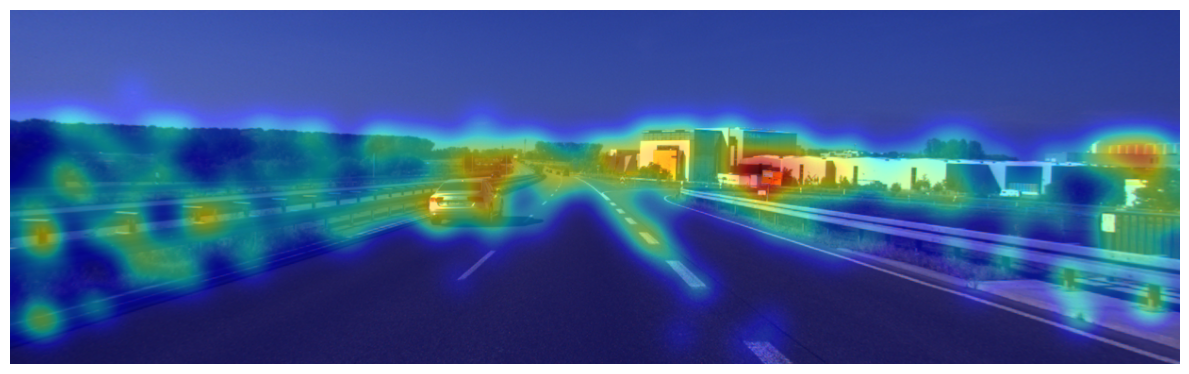

发生错误: name 'keypoints' is not defined


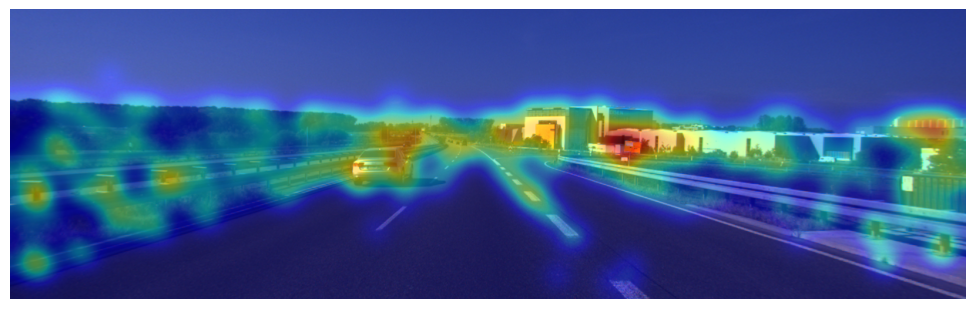

In [ ]:
image_path = "000500.png"
output_pdf_path = "000500.pdf"

try:
    result_image, num_keypoints = create_and_display_orb_heatmap(
        image_path, output_pdf_path, max_keypoints=2000, sigma=15, alpha=0.5
    )

except Exception as e:
    print(f"发生错误: {e}")